# What Does Minecraft Server's Packet Statistics Look Like?
### A Network Traffic Analysis of Hypixel Lobby Traffic and Comparison with Roblox

This analysis covers the traffic one receives simply by existing in a Minecraft server lobby. And what kinds of information is being transmitted between you and the server. An additional quick analysis is done on Roblox for comparison.

---
**Setup:** Captured via `tcpdump` on port 25565 during a Hypixel lobby session. Analyzed with `pyshark`.

In [2]:
# Setup — run this first
import nest_asyncio; nest_asyncio.apply()
import pyshark, os, numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict, Counter

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c8cdd8',
    'xtick.color':      '#8890a8',
    'ytick.color':      '#8890a8',
    'text.color':       '#c8cdd8',
    'grid.color':       '#2e3250',
    'grid.linestyle':   '--',
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#2e3250',
})

TSHARK_PATH = '/Applications/Wireshark.app/Contents/MacOS/tshark'
PCAP        = os.path.expanduser('./minecraft_capture.pcap')
PCAP_ROBLOX        = os.path.expanduser('./roblox_capture.pcap')

print(f"File: {PCAP}")
print(f"Size: {os.path.getsize(PCAP)/1e6:.1f} MB")
print("Ready.")

File: ./minecraft_capture.pcap
Size: 21.1 MB
Ready.


---
## Lobby Volume

First, we measure the amount of packets being sent and received in the lobby.
Generally, without an active game going on, one would assume there isn't much to be sent to the lobby but..

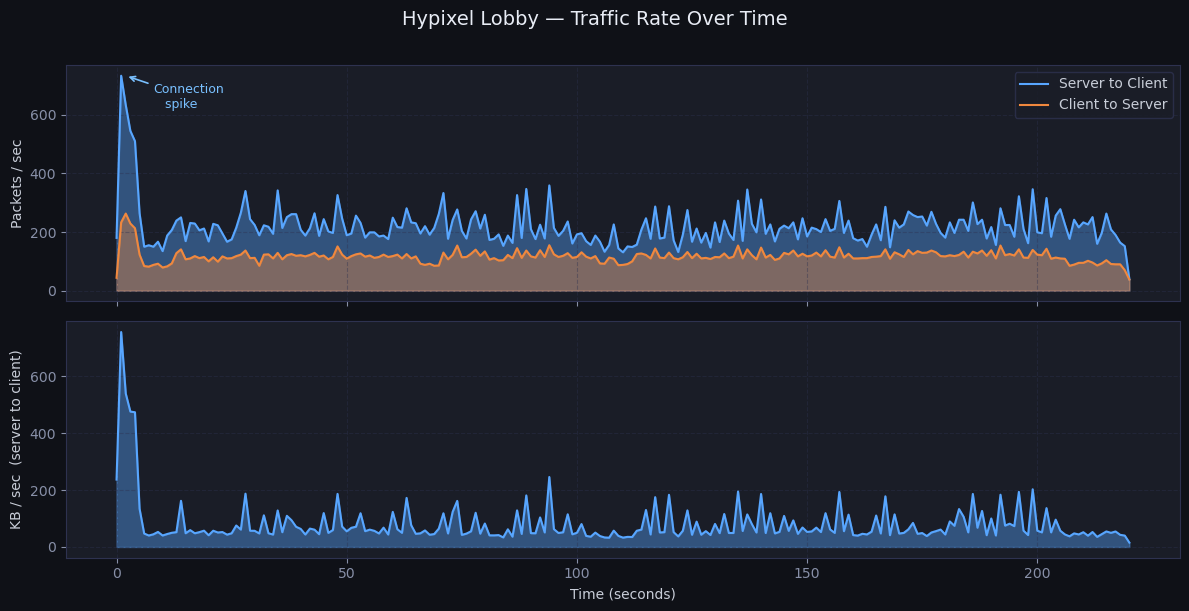

Total packets:    74,860
Total data:       19.9 MB
Duration:         221s
Avg packet rate:  339 pkt/s  (20324 pkt/min)
Avg throughput:   720 kbps


In [16]:
cap = pyshark.FileCapture(PCAP, tshark_path=TSHARK_PATH)

#client to server packets/sec
pps_c = defaultdict(int)  
#server to client packet/sec
pps_s = defaultdict(int)  
#server to client bytes/sec
bps_s = defaultdict(int) 
total_pkts  = 0
total_bytes = 0
start_time  = None

for pkt in cap:
    try:
        t = float(pkt.sniff_timestamp)
        if start_time is None: start_time = t
        bucket = int(t - start_time)
        size   = int(pkt.length)
        total_pkts  += 1
        total_bytes += size
        if not hasattr(pkt, 'tcp'): continue
        if pkt.tcp.dstport == '25565':
            pps_c[bucket] += 1
        else:
            pps_s[bucket] += 1
            bps_s[bucket] += size
    except: pass

cap.close()
duration = max(max(pps_s.keys(), default=0), max(pps_c.keys(), default=0)) + 1
secs = list(range(duration))

# ── Plot ──
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle('Hypixel Lobby — Traffic Rate Over Time', fontsize=14, color='#e8ecf5', y=1.01)

ax = axes[0]
ax.fill_between(secs, [pps_s.get(s,0) for s in secs], alpha=0.4, color='#58a6ff')
ax.plot(secs, [pps_s.get(s,0) for s in secs], color='#58a6ff', lw=1.5, label='Server to Client')
ax.fill_between(secs, [pps_c.get(s,0) for s in secs], alpha=0.4, color='#f0883e')
ax.plot(secs, [pps_c.get(s,0) for s in secs], color='#f0883e', lw=1.5, label='Client to Server')
ax.set_ylabel('Packets / sec')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
ax.annotate('Connection\n   spike', xy=(2, max(pps_s.get(s,0) for s in secs[:5])),
            xytext=(8, max(pps_s.get(s,0) for s in secs[:5])*0.85),
            color='#79c0ff', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#79c0ff', lw=1.2))

ax2 = axes[1]
ax2.fill_between(secs, [bps_s.get(s,0)/1e3 for s in secs], alpha=0.4, color='#58a6ff')
ax2.plot(secs, [bps_s.get(s,0)/1e3 for s in secs], color='#58a6ff', lw=1.5)
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('KB / sec  (server to client)')
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('finding1_volume.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

avg_pps = total_pkts / duration
print(f"Total packets:    {total_pkts:,}")
print(f"Total data:       {total_bytes/1e6:.1f} MB")
print(f"Duration:         {duration}s")
print(f"Avg packet rate:  {avg_pps:.0f} pkt/s  ({avg_pps*60:.0f} pkt/min)")
print(f"Avg throughput:   {total_bytes*8/duration/1e3:.0f} kbps")

A decent amount of activity is being done at all time just for existing in the lobby.

A lot of player information has to be repeatedly updated, each player's status, server information, all has to be maintained even when nothing explicit is being done.

Furthermore, there is a spike when the connection is first established as the world information and server status has to be loaded on to the client when the connection is made.

---
## TCP's Cost

Minecraft Java Edition uses TCP as it's Transport protocol, unlike many other games. Because of this, we can measure the RTT and see how much overhead retransmissions bring.

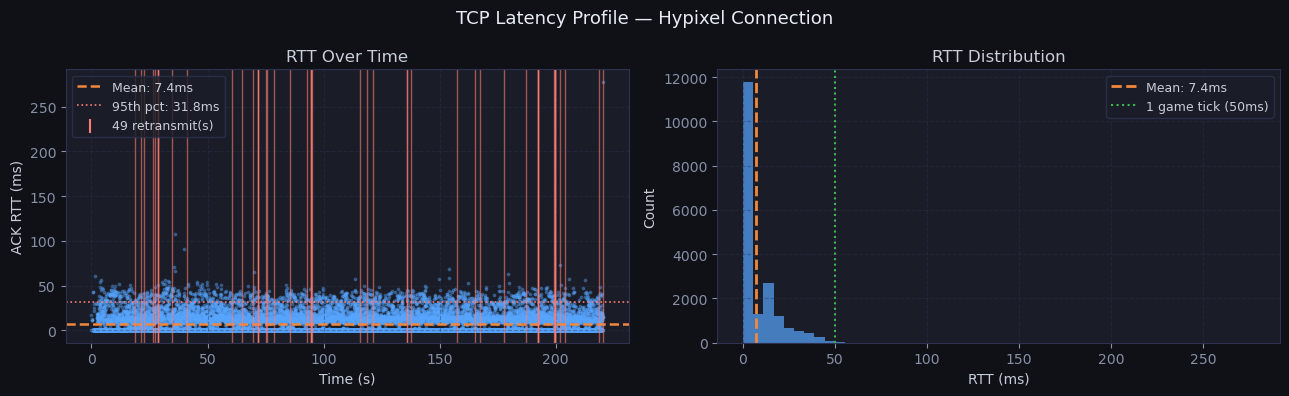

Mean RTT:         7.4 ms
95th percentile:  31.8 ms
Std deviation:    11.1 ms
Retransmissions:  49

Minecraft runs at 20 ticks/sec → 1 tick = 50ms
A 95th-pct retransmit stalls ~0.6 game ticks


In [5]:
cap = pyshark.FileCapture(PCAP, tshark_path=TSHARK_PATH,
                          display_filter='tcp.analysis.ack_rtt')
rtts, times = [], []
t0 = None
for pkt in cap:
    try:
        rtt = float(pkt.tcp.analysis_ack_rtt) * 1000
        t   = float(pkt.sniff_timestamp)
        if t0 is None: t0 = t
        if rtt < 1000:
            rtts.append(rtt)
            times.append(t - t0)
    except: pass
cap.close()

# Retransmissions
cap2 = pyshark.FileCapture(PCAP, tshark_path=TSHARK_PATH,
    display_filter='tcp.analysis.retransmission or tcp.analysis.fast_retransmission')
retrans_times = []
for pkt in cap2:
    try:
        t = float(pkt.sniff_timestamp) - t0
        retrans_times.append(t)
    except: pass
cap2.close()

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('TCP Latency Profile — Hypixel Connection', fontsize=13, color='#e8ecf5')

# RTT over time
ax = axes[0]
ax.scatter(times, rtts, s=3, alpha=0.35, color='#58a6ff')
mean_rtt = np.mean(rtts)
ax.axhline(mean_rtt, color='#f0883e', lw=1.8, linestyle='--', label=f'Mean: {mean_rtt:.1f}ms')
ax.axhline(np.percentile(rtts, 95), color='#ff7b72', lw=1.2, linestyle=':',
           label=f'95th pct: {np.percentile(rtts,95):.1f}ms')
if retrans_times:
    for rt in retrans_times:
        ax.axvline(rt, color='#ff7b72', alpha=0.6, lw=1)
    ax.scatter([], [], color='#ff7b72', label=f'{len(retrans_times)} retransmit(s)', marker='|', s=100)
ax.set_xlabel('Time (s)')
ax.set_ylabel('ACK RTT (ms)')
ax.set_title('RTT Over Time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# RTT histogram
ax2 = axes[1]
ax2.hist(rtts, bins=50, color='#58a6ff', alpha=0.7, edgecolor='none')
ax2.axvline(mean_rtt, color='#f0883e', lw=2, linestyle='--', label=f'Mean: {mean_rtt:.1f}ms')
ax2.axvline(50, color='#3fb950', lw=1.5, linestyle=':',
            label='1 game tick (50ms)')
ax2.set_xlabel('RTT (ms)')
ax2.set_ylabel('Count')
ax2.set_title('RTT Distribution')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('finding2_rtt.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

ticks_delayed = np.percentile(rtts, 95) / 50
print(f"Mean RTT:         {mean_rtt:.1f} ms")
print(f"95th percentile:  {np.percentile(rtts,95):.1f} ms")
print(f"Std deviation:    {np.std(rtts):.1f} ms")
print(f"Retransmissions:  {len(retrans_times)}")
print(f"")
print(f"Minecraft runs at 20 ticks/sec → 1 tick = 50ms")
print(f"A 95th-pct retransmit stalls ~{ticks_delayed:.1f} game ticks")

We can see that although the connection is good, there are indeed some retransmits due to the nature of transporting information.

At the 95th percentile (to avoid outliers), we stall with a high end of about 31ms, and retransmits happen very infrequently as well.

---
## Traffic Distribution

We can then ask, why does Minecraft use TCP rather than UDP? One hint can be found looking at how much data comes from which source (by bits)

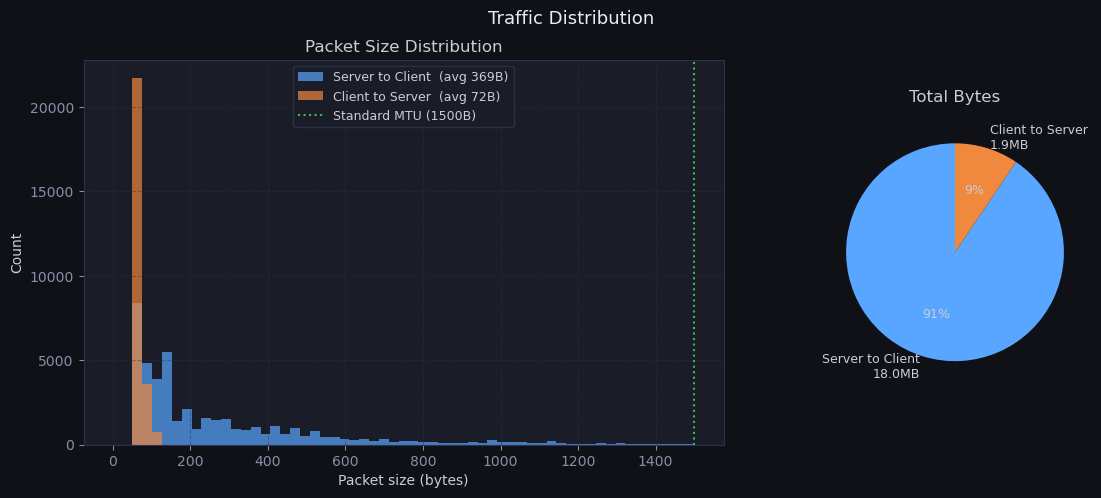

Server to Client:  48,856 packets, 18.01 MB
Client to Server:  26,004 packets, 1.88 MB
Asymmetry ratio: 9.6x more data downloaded than uploaded

Number of packets over 500B
  10,568 packets  (21.6% of server traffic)


In [7]:
cap = pyshark.FileCapture(PCAP, tshark_path=TSHARK_PATH)

sizes_c, sizes_s = [], []
for pkt in cap:
    try:
        if not hasattr(pkt, 'tcp'): continue
        size = int(pkt.length)
        if pkt.tcp.dstport == '25565': sizes_c.append(size)
        else: sizes_s.append(size)
    except: pass
cap.close()

# ── Plot ──
fig = plt.figure(figsize=(13, 5))
fig.suptitle('Traffic Distribution', fontsize=13, color='#e8ecf5')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Packet size distributions
ax1 = fig.add_subplot(gs[0, :2])
bins = np.linspace(0, 1500, 60)
ax1.hist(sizes_s, bins=bins, alpha=0.7, color='#58a6ff',
         label=f'Server to Client  (avg {np.mean(sizes_s):.0f}B)', edgecolor='none')
ax1.hist(sizes_c, bins=bins, alpha=0.7, color='#f0883e',
         label=f'Client to Server  (avg {np.mean(sizes_c):.0f}B)', edgecolor='none')
ax1.axvline(1500, color='#3fb950', lw=1.5, linestyle=':', label='Standard MTU (1500B)')
ax1.set_xlabel('Packet size (bytes)')
ax1.set_ylabel('Count')
ax1.set_title('Packet Size Distribution')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.4)

# Bytes pie
ax2 = fig.add_subplot(gs[0, 2])
total_s = sum(sizes_s)
total_c = sum(sizes_c)
ax2.pie([total_s, total_c],
        labels=[f'Server to Client\n{total_s/1e6:.1f}MB',
                f'Client to Server\n{total_c/1e6:.1f}MB'],
        colors=['#58a6ff', '#f0883e'],
        autopct='%1.0f%%', startangle=90,
        textprops={'color': '#c8cdd8', 'fontsize': 9})
ax2.set_title('Total Bytes', pad=10)

plt.savefig('finding3_asymmetry.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

ratio = total_s / max(total_c, 1)
print(f"Server to Client:  {len(sizes_s):,} packets, {total_s/1e6:.2f} MB")
print(f"Client to Server:  {len(sizes_c):,} packets, {total_c/1e6:.2f} MB")
print(f"Asymmetry ratio: {ratio:.1f}x more data downloaded than uploaded")
print()
print("Number of packets over 500B")
large = [s for s in sizes_s if s > 500]
print(f"  {len(large):,} packets  ({len(large)/len(sizes_s)*100:.1f}% of server traffic)")

As we can see, the amount received from the server is much, much higher than the information given to the player.

One can surmise a lot of this data contains world information, mainly information about chunks and spawning.
This data is stateful and depends on the information behind it, like what was placed and what was broken. So ensuring this data is reliably transferred makes the game more coherent between players.

---
## Bedrock

One interesting thing to note is that Minecraft Bedrock Edition uses UDP. Although I do not go into it here (as I do not have an account for it), this can be seen as an improvement as Bedrock Edition was created from the ground up as an improvement to the original Java edition, and thus attempts to use UDP's benefits such as lower latency. Instead for reliability, it uses RakNet, which is a networking engine that is built on top of UDP to resolve reliability issues.

However, as Bedrock Edition has had many example of players dying from seemingly nothing, or moments of severe desynchronization from the server, we can observe why many players choose to play on Java instead.

---
# Additional Information
## Receive Window

Another part that warranted analysis was the receive window of the capture. I wanted to see how it changes as information being sent changes from the initial connection to the steady state.

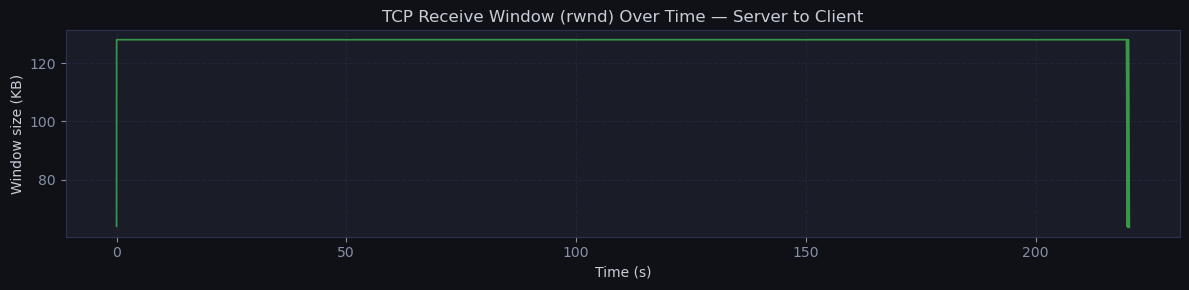

Mean rwnd:   128.0 KB
Min rwnd:    63.6 KB
Max rwnd:    128.0 KB



In [9]:
cap = pyshark.FileCapture(PCAP, tshark_path=TSHARK_PATH)

rwnd_times  = []
rwnd_values = []
t0 = None

for pkt in cap:
    try:
        if not hasattr(pkt, 'tcp'): continue
        # Only look at server→client packets (Hypixel advertising its receive window)
        if pkt.tcp.srcport != '25565': continue
        
        t = float(pkt.sniff_timestamp)
        if t0 is None: t0 = t
        
        rwnd = int(pkt.tcp.window_size)  # bytes the sender is willing to receive
        rwnd_times.append(t - t0)
        rwnd_values.append(rwnd / 1024)  # convert to KB for readability
    except: pass

cap.close()

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(rwnd_times, rwnd_values, color='#3fb950', lw=1.2, alpha=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Window size (KB)')
ax.set_title('TCP Receive Window (rwnd) Over Time — Server to Client', fontsize=12)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('rwnd.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(f"Mean rwnd:   {sum(rwnd_values)/len(rwnd_values):.1f} KB")
print(f"Min rwnd:    {min(rwnd_values):.1f} KB")
print(f"Max rwnd:    {max(rwnd_values):.1f} KB")
print()

Unfortunately, it appears that there's not much going on, given that our intial window is large enough to keep all the data the server sends per packet.

---
## TTL Counts

A quick check of TTL reveals there isn't anything special going on communicating with the servers.

In [4]:
cap = pyshark.FileCapture(PCAP, tshark_path=TSHARK_PATH)

ttls = []
for pkt in cap:
    try:
        if not hasattr(pkt, 'tcp'): continue
        # Only server→client packets (Hypixel's TTL)
        if pkt.tcp.srcport != '25565': continue
        ip = pkt.ip if hasattr(pkt, 'ip') else pkt.ipv6
        ttls.append(int(ip.ttl))
    except: pass

cap.close()

ttl_counts = Counter(ttls)
print("TTL distribution (server→client packets):")
for ttl, count in sorted(ttl_counts.items(), reverse=True):
    print(f"  TTL {ttl:<6} {count:>8,} packets")

print()
most_common_ttl = ttl_counts.most_common(1)[0][0]
# Infer starting TTL
if most_common_ttl > 64:
    starting_ttl = 128
else:
    starting_ttl = 64
hops = starting_ttl - most_common_ttl
print(f"Most common TTL:  {most_common_ttl}")
print(f"Inferred starting TTL: {starting_ttl}")
print(f"Estimated hops from Hypixel to you: {hops}")

TTL distribution (server→client packets):
  TTL 56       48,842 packets
  TTL 51           14 packets

Most common TTL:  56
Inferred starting TTL: 64
Estimated hops from Hypixel to you: 8


---
## Roblox

## Data Distribution in Roblox

Although I do not have Minecraft Bedrock Edition, I did want to see how traffic looks on a game that uses UDP. As such, I used a capture of Roblox's "Tower of Hell" game (it's a parkour challenge) to see how different the packets are there.

First, we take a look at the data distribution to compare to how Minecraft did it.

In [17]:
# Pass 1 — find server IP
cap = pyshark.FileCapture(PCAP_ROBLOX, tshark_path=TSHARK_PATH)
ip_counts = Counter()
for pkt in cap:
    try:
        if not hasattr(pkt, 'udp'): continue
        ip = pkt.ip if hasattr(pkt, 'ip') else pkt.ipv6
        ip_counts[ip.src] += 1
        ip_counts[ip.dst] += 1
    except: pass
cap.close()

print("Top IPs — for figuring out which is from Roblox")
for ip, count in ip_counts.most_common(5):
    print(f"  {ip:<40} {count} packets")

Top IPs — for figuring out which is from Roblox
  10.0.0.157                               24369 packets
  128.116.32.33                            24167 packets
  2601:19b:701:8110:95fc:d1bb:d542:c74c    332 packets
  142.250.65.78                            192 packets
  239.255.255.250                          141 packets


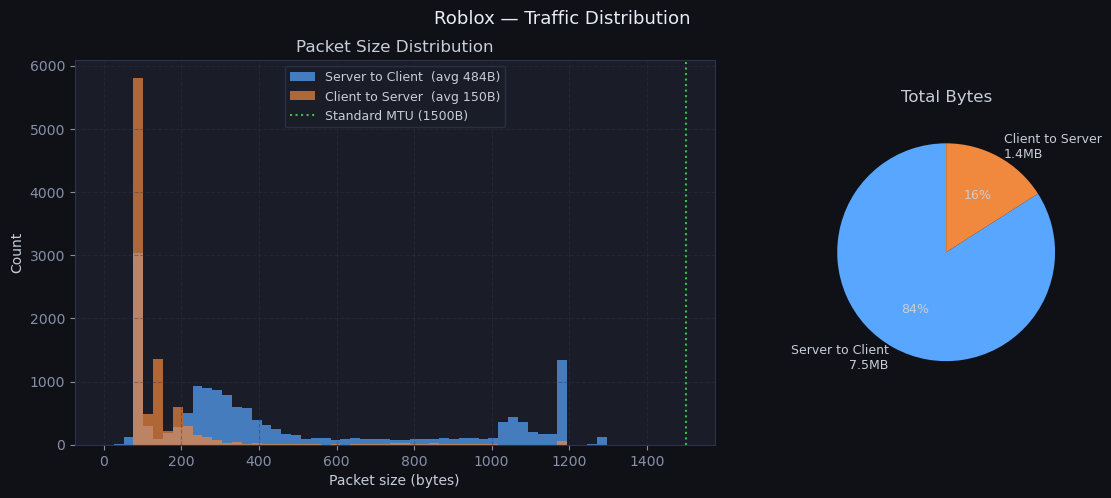

Server to Client:  15,492 packets, 7.50 MB
Client to Server:  9,505 packets, 1.43 MB
Asymmetry ratio:   5.3x more data downloaded than uploaded

Number of packets over 500B:
  5,116 packets  (33.0% of server traffic)


In [14]:
SERVER_IP = '128.116.32.33'  

cap = pyshark.FileCapture(PCAP_ROBLOX, tshark_path=TSHARK_PATH)
sizes_c, sizes_s = [], []

for pkt in cap:
    try:
        if not hasattr(pkt, 'udp'): continue
        ip = pkt.ip if hasattr(pkt, 'ip') else pkt.ipv6
        size = int(pkt.length)
        if ip.dst == SERVER_IP:
            sizes_c.append(size)
        else:
            sizes_s.append(size)
    except: pass

cap.close()

# ── Plot ──
fig = plt.figure(figsize=(13, 5))
fig.suptitle('Roblox — Traffic Distribution', fontsize=13, color='#e8ecf5')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
bins = np.linspace(0, 1500, 60)
ax1.hist(sizes_s, bins=bins, alpha=0.7, color='#58a6ff',
         label=f'Server to Client  (avg {np.mean(sizes_s):.0f}B)', edgecolor='none')
ax1.hist(sizes_c, bins=bins, alpha=0.7, color='#f0883e',
         label=f'Client to Server  (avg {np.mean(sizes_c):.0f}B)', edgecolor='none')
ax1.axvline(1500, color='#3fb950', lw=1.5, linestyle=':', label='Standard MTU (1500B)')
ax1.set_xlabel('Packet size (bytes)')
ax1.set_ylabel('Count')
ax1.set_title('Packet Size Distribution')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.4)

ax2 = fig.add_subplot(gs[0, 2])
total_s = sum(sizes_s)
total_c = sum(sizes_c)
ax2.pie([total_s, total_c],
        labels=[f'Server to Client\n{total_s/1e6:.1f}MB',
                f'Client to Server\n{total_c/1e6:.1f}MB'],
        colors=['#58a6ff', '#f0883e'],
        autopct='%1.0f%%', startangle=90,
        textprops={'color': '#c8cdd8', 'fontsize': 9})
ax2.set_title('Total Bytes', pad=10)

plt.savefig('roblox_finding3_asymmetry.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

ratio = total_s / max(total_c, 1)
print(f"Server to Client:  {len(sizes_s):,} packets, {total_s/1e6:.2f} MB")
print(f"Client to Server:  {len(sizes_c):,} packets, {total_c/1e6:.2f} MB")
print(f"Asymmetry ratio:   {ratio:.1f}x more data downloaded than uploaded")
print()
print("Number of packets over 500B:")
large = [s for s in sizes_s if s > 500]
print(f"  {len(large):,} packets  ({len(large)/len(sizes_s)*100:.1f}% of server traffic)")

Looking at it, it appears very similar to that of MInecraft in the form of its shape on packet size.

However, one thing to note is the total number of bytes being sent. Although the amount from the client is about the same, the amount from the server has decreased by about half.

This shows the difference between the game updates of Minecraft with an importance of world state and the Tower of Hell minigame which has a much more static world.

---

## Volume in Roblox

Looking at the similar shape that Roblox has in the sense of packet size, I was intrigued and wanted to see what the volume looked like as well.

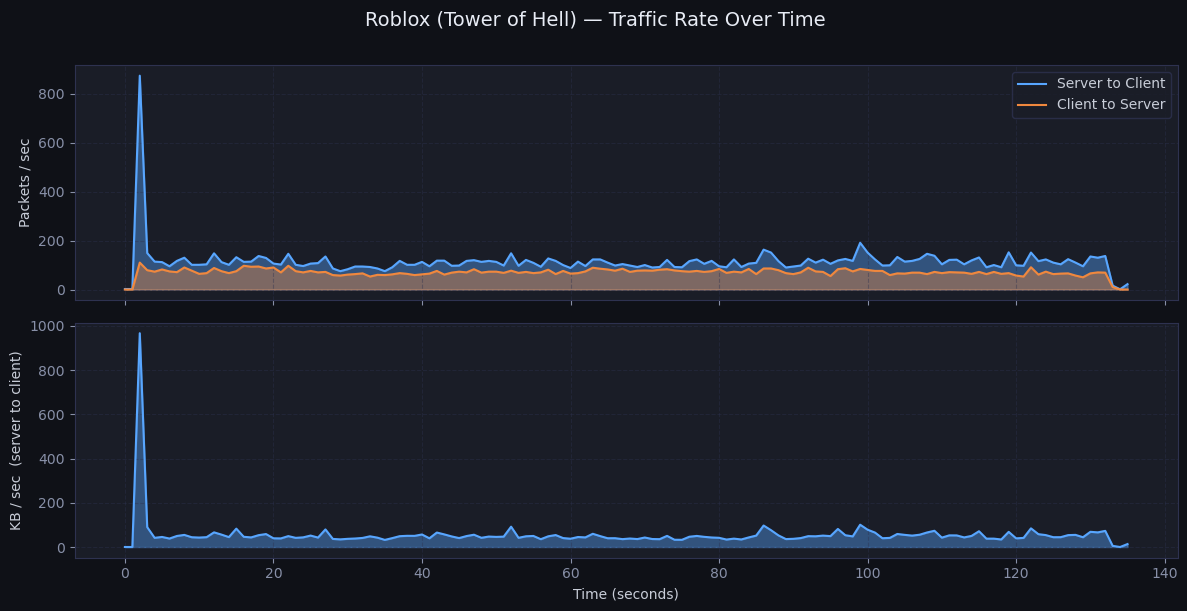

Total packets:    25,018
Total data:       9.0 MB
Duration:         136s
Avg packet rate:  184 pkt/s  (11037 pkt/min)
Avg throughput:   527 kbps


In [15]:
SERVER_IP = '128.116.32.33'

cap = pyshark.FileCapture(PCAP_ROBLOX, tshark_path=TSHARK_PATH)
pps_c = defaultdict(int)
pps_s = defaultdict(int)
bps_s = defaultdict(int)
total_pkts  = 0
total_bytes = 0
start_time  = None

for pkt in cap:
    try:
        t = float(pkt.sniff_timestamp)
        if start_time is None: start_time = t
        bucket = int(t - start_time)
        size   = int(pkt.length)
        total_pkts  += 1
        total_bytes += size
        if not hasattr(pkt, 'udp'): continue
        ip = pkt.ip if hasattr(pkt, 'ip') else pkt.ipv6
        if ip.dst == SERVER_IP:
            pps_c[bucket] += 1
        else:
            pps_s[bucket] += 1
            bps_s[bucket] += size
    except: pass

cap.close()
duration = max(max(pps_s.keys(), default=0), max(pps_c.keys(), default=0)) + 1
secs = list(range(duration))

# ── Plot ──
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle('Roblox (Tower of Hell) — Traffic Rate Over Time', fontsize=14, color='#e8ecf5', y=1.01)

ax = axes[0]
ax.fill_between(secs, [pps_s.get(s,0) for s in secs], alpha=0.4, color='#58a6ff')
ax.plot(secs, [pps_s.get(s,0) for s in secs], color='#58a6ff', lw=1.5, label='Server to Client')
ax.fill_between(secs, [pps_c.get(s,0) for s in secs], alpha=0.4, color='#f0883e')
ax.plot(secs, [pps_c.get(s,0) for s in secs], color='#f0883e', lw=1.5, label='Client to Server')
ax.set_ylabel('Packets / sec')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)

ax2 = axes[1]
ax2.fill_between(secs, [bps_s.get(s,0)/1e3 for s in secs], alpha=0.4, color='#58a6ff')
ax2.plot(secs, [bps_s.get(s,0)/1e3 for s in secs], color='#58a6ff', lw=1.5)
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('KB / sec  (server to client)')
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('roblox_finding1_volume.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

avg_pps = total_pkts / duration
print(f"Total packets:    {total_pkts:,}")
print(f"Total data:       {total_bytes/1e6:.1f} MB")
print(f"Duration:         {duration}s")
print(f"Avg packet rate:  {avg_pps:.0f} pkt/s  ({avg_pps*60:.0f} pkt/min)")
print(f"Avg throughput:   {total_bytes*8/duration/1e3:.0f} kbps")

The outcome was predicatably much like that of Minecraft's. However, one interesting to note is that there is much less spikes than there is in Minecraft, and shows how there isn't large server updates being sent over to the client after the initial connection.

---
## Conclusion

Looking at the traffic from both Minecraft and Roblox, we can see that they are very similar despite using different prototypes. The underlying protocol ultimately does not change what regular activity looks like when the client and server are communicating. However, they do play a crucial role when activity is not normal. Ultimately, the game design philosophys between the two show how each protocol is chosen.

---
*Capture: tcpdump on port 25565, Hypixel lobby, ~2.5 min. tcpdump on all ports for Roblox, Tower of Hell, also about 2.5 mins. Analysis: pyshark + matplotlib.*

TTL distribution (server→client packets):
  TTL 56       48,842 packets
  TTL 51           14 packets

Most common TTL:  56
Inferred starting TTL: 64
Estimated hops from Hypixel to you: 8
